# Results

A Bayesian workflow on a simple straight-line regression, taken from the
posterior the No-U-Turn sampler produces. We move through it in order:
1. the model and its priors;
2. what those priors imply before any data is seen;
3. then the fitted posterior of each parameter and the posterior predictive, shown
first as an ensemble of fitted lines and then as a single best line with
credible and predictive bounds.

This is the only notebook that runs the sampler. It saves the run and a few
derived quantities to `outputs/notebook_run`; the Diagnostics and Calibration
notebooks read that directory and never refit. The model is conjugate, so
every sampled quantity has a closed-form reference to check against.

## The model

Observe $n$ responses $y_i$ at scalar inputs $x_i$ and model them as a
straight line with Gaussian noise,

$$ y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad
   \varepsilon_i \sim \mathcal{N}(0, \sigma^2). $$

I place a conjugate Normal-Inverse-Gamma prior on the coefficients $\beta$ and
the noise variance $\sigma^2$. Conjugacy ensure the posterior is available in closed form, which gives an exact reference to check the sampler against.
The sampler works in the unconstrained vector
$z = (\beta, \log\sigma)$ so the scale can move on the whole Real line.

In [1]:
import sys
from pathlib import Path

# The project root is the directory holding src/toynuts. From it we put the
# package on the path (no install needed) and fix one run directory the three
# notebooks share: Results writes it, Diagnostics and Calibration read it.
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "toynuts").is_dir()),
    Path.cwd(),
)
if not any((Path(p) / "toynuts").is_dir() for p in sys.path):
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
RUN_DIR = PROJECT_ROOT / "outputs" / "notebook_run"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sps
from scipy.special import polygamma

from toynuts.models.linear_gaussian import LinearGaussian
from toynuts.sampler import SamplerConfig, sample
from toynuts.io import to_dataframes, write_run
from toynuts.calibration import rank_statistic

plt.rcParams["figure.dpi"] = 110

# A simple linear regression: one input x, an intercept and Gaussian noise. The
# data seed is a representative draw, one where the posterior settles close to the
# generating values rather than an unlucky outlier.
data_rng = np.random.default_rng(131)
n = 80
x = np.sort(data_rng.uniform(-2.5, 2.5, n))
X = np.column_stack([np.ones(n), x])
beta_true = np.array([1.0, 2.0])          # intercept, slope
sigma_true = 1.0
y = X @ beta_true + sigma_true * data_rng.standard_normal(n)

# Conjugate Normal-Inverse-Gamma prior. V0 is deliberately wide so the prior is
# weakly informative; the posterior will turn out roughly ten times tighter.
m0 = np.zeros(2)
V0 = np.diag([2.0, 2.0])
a0, b0 = 6.0, 5.0
model = LinearGaussian(X, y, m0, V0, a0, b0)


def matched_metric(mdl):
    """Fixed diagonal metric from the analytic posterior variances.

    The beta block uses the marginal posterior variances; the scale uses
    Var[log sigma] = 0.25 * trigamma(a_n). Nothing here is adapted during sampling.
    """
    mom = mdl.analytic_posterior_moments()
    var_z = np.concatenate([np.diag(mom["beta_cov"]), [0.25 * polygamma(1, mdl.a_n)]])
    return np.diag(1.0 / var_z)

print(f"observations n = {model.n}, coefficients p = {model.p}, dim z = {model.dim}")
print("parameters:", model.param_names)

observations n = 80, coefficients p = 2, dim z = 3
parameters: ['beta_0', 'beta_1', 'sigma']


## The priors of each parameter

Before fitting, the prior says what we believe about each parameter. The
histograms are a large i.i.d. draw from the prior; the solid curves are the
analytic marginals (a Student-t for each coefficient, the transformed
Inverse-Gamma for the scale). The dashed line marks the value that generated
the data, well inside the prior in every case. The final panel repeats the
scale as $u = \log\sigma$, the space the sampler actually works in.

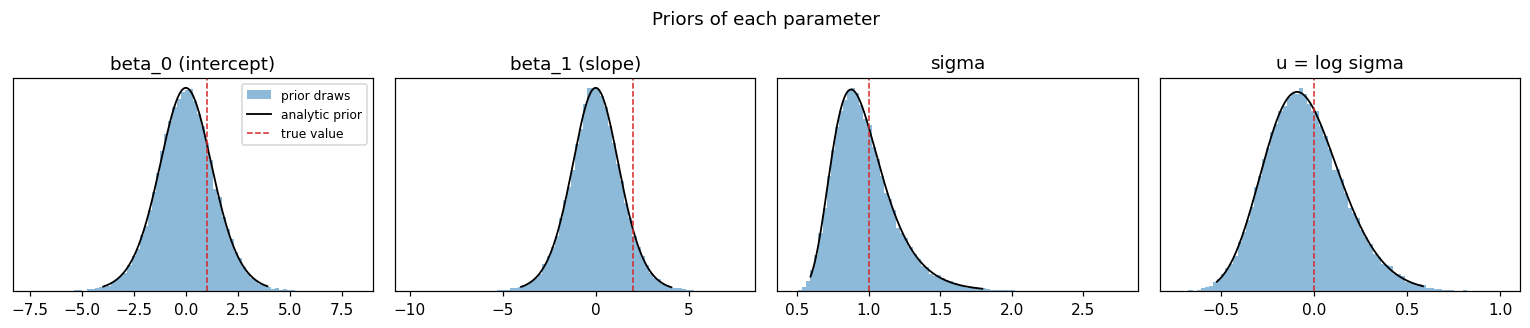

In [2]:
prior = model.prior_draws(40000, np.random.default_rng(10))
# Append u = log sigma, the scale in the space the sampler works in.
prior = np.column_stack([prior, np.log(prior[:, 2])])
names = ["beta_0 (intercept)", "beta_1 (slope)", "sigma", "u = log sigma"]
truth = [beta_true[0], beta_true[1], sigma_true, np.log(sigma_true)]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for k, ax in enumerate(axes):
    ax.hist(prior[:, k], bins=80, density=True, alpha=0.5, color="C0", label="prior draws")
    grid = np.linspace(*np.quantile(prior[:, k], [0.005, 0.995]), 300)
    if k < 2:
        scale = np.sqrt((b0 / a0) * V0[k, k])
        pdf = sps.t(df=2 * a0, loc=m0[k], scale=scale).pdf(grid)
    elif k == 2:
        # sigma = sqrt(sigma**2) with sigma**2 ~ IG, so multiply by the Jacobian 2 sigma.
        pdf = sps.invgamma(a=a0, scale=b0).pdf(grid**2) * 2 * grid
    else:
        # u = 0.5 log sigma**2, whose density carries the Jacobian 2 exp(2u).
        pdf = sps.invgamma(a=a0, scale=b0).pdf(np.exp(2 * grid)) * 2 * np.exp(2 * grid)
    ax.plot(grid, pdf, "k", lw=1.2, label="analytic prior")
    ax.axvline(truth[k], color="C3", ls="--", lw=1, label="true value")
    ax.set_title(names[k])
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.suptitle("Priors of each parameter")
fig.tight_layout()
plt.show()

## Prior predictive: what the priors imply for the line

Pushing prior draws of $(\beta, \sigma)$ through the model gives lines the
prior considers plausible. They fan out widely and pay no attention to the
data, which is what a weakly informative prior should look like.

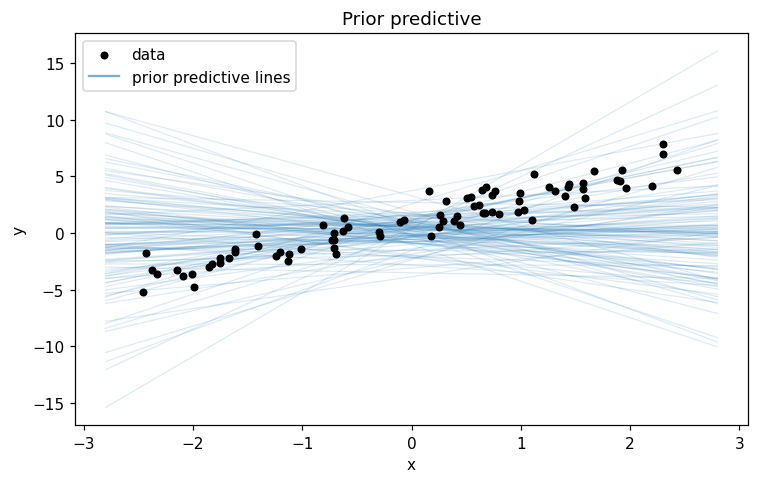

In [3]:
grid_x = np.linspace(-2.8, 2.8, 120)
grid_X = np.column_stack([np.ones_like(grid_x), grid_x])
prior_lines = model.predictive_draws(model.prior_draws(120, np.random.default_rng(11)), grid_X)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(grid_x, prior_lines.T, color="C0", alpha=0.15, lw=0.8)
ax.scatter(x, y, s=18, color="k", zorder=3, label="data")
ax.plot([], [], color="C0", alpha=0.6, label="prior predictive lines")
ax.set(xlabel="x", ylabel="y", title="Prior predictive")
ax.legend()
fig.tight_layout()
plt.show()

## Fitting the posterior

I run four chains of NUTS with a fixed step size and a metric matched to the
analytic posterior scales, then save the run straight away so the Diagnostics
notebook can read it. The run is checked in full there; here we only confirm
it is clean and keep the draws.

In [4]:
config = SamplerConfig(n_chains=4, n_draws=2000, step_size=0.3, metric=matched_metric(model), seed=2)
run = sample(model, config)
draws, stats, run_config = to_dataframes(run, config, model)
post = draws[["beta_0", "beta_1", "sigma"]].to_numpy()

RUN_DIR.mkdir(parents=True, exist_ok=True)
write_run(RUN_DIR, draws, stats, run_config)
print("saved run to", RUN_DIR)
print("posterior draws:", post.shape[0], " divergences:", int(stats["divergent"].sum()))

saved run to /home/s95717/data_science_public/toy-nuts-bayes/outputs/notebook_run
posterior draws: 8000  divergences: 0


## The posterior of each parameter

The sampled marginals (filled) sit on top of exact i.i.d. draws from the
closed-form posterior (outline). They agree, and both have collapsed from the
wide prior of a moment ago onto a tight band around the true values. The
posterior mean lands near each true value but not exactly on it: with finite
data the centre is the truth plus a little noise, and the width is how much
that centre could still be off. The final panel shows the same recovery for
$u = \log\sigma$, the scale in the sampler's space, more symmetric than the
$\sigma$ it came from.

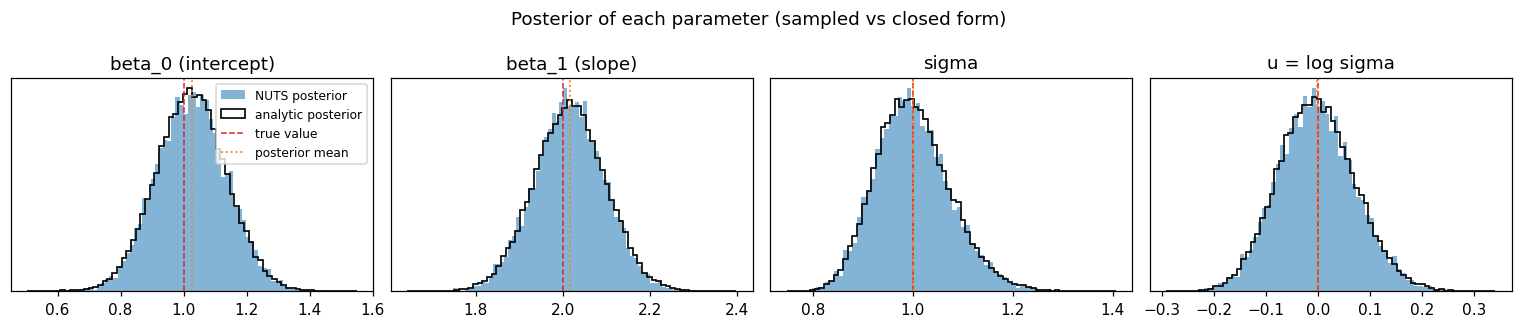

In [5]:
ref = model.analytic_posterior_draws(40000, np.random.default_rng(12))
# Append u = log sigma to the sampled and the reference draws.
post_u = np.column_stack([post, np.log(post[:, 2])])
ref_u = np.column_stack([ref, np.log(ref[:, 2])])

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for k, ax in enumerate(axes):
    ax.hist(post_u[:, k], bins=70, density=True, alpha=0.55, color="C0", label="NUTS posterior")
    ax.hist(ref_u[:, k], bins=70, density=True, histtype="step", color="k", lw=1.1,
            label="analytic posterior")
    ax.axvline(truth[k], color="C3", ls="--", lw=1, label="true value")
    ax.axvline(post_u[:, k].mean(), color="C1", ls=":", lw=1.2, label="posterior mean")
    ax.set_title(names[k])
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.suptitle("Posterior of each parameter (sampled vs closed form)")
fig.tight_layout()
plt.show()

## A quantitative check against the closed form

The overlay above is convincing by eye - here it is in numbers.

For each parameter we compare the sampled posterior mean and standard deviation against
the exact Normal-Inverse-Gamma values (for $\sigma$ these come from the moments
of the square root of an Inverse-Gamma). The yardstick for the mean is the Monte
Carlo standard error: the column $z$ is the discrepancy in MCSE units, so values
within a few are sampling noise rather than bias. The spread is read off the
ratio of sampled to analytic standard deviation, which should sit at one.

In [6]:
from scipy.special import gammaln

from toynuts.diagnostics import mcse_mean

mom = model.analytic_posterior_moments()
mcse = mcse_mean(draws)

# Analytic posterior mean and sd of each stored parameter. The beta moments are
# read straight off the closed form; for sigma we use the moments of the square
# root of an Inverse-Gamma, E[sigma**k] = b_n**(k/2) * Gamma(a_n - k/2) / Gamma(a_n),
# which give the mean and, with E[sigma**2] = b_n / (a_n - 1), the variance.
a_n, b_n = model.a_n, model.b_n
sigma_mean = np.sqrt(b_n) * np.exp(gammaln(a_n - 0.5) - gammaln(a_n))
sigma_sd = np.sqrt(b_n / (a_n - 1.0) - sigma_mean**2)
analytic_mean = np.array([mom["beta_mean"][0], mom["beta_mean"][1], sigma_mean])
analytic_sd = np.array([np.sqrt(mom["beta_cov"][0, 0]), np.sqrt(mom["beta_cov"][1, 1]), sigma_sd])

names = ["beta_0", "beta_1", "sigma"]
sampled_mean = post.mean(0)
sampled_sd = post.std(0, ddof=1)
mcse_vec = mcse[names].to_numpy()

check = pd.DataFrame(
    {
        "analytic mean": analytic_mean,
        "sampled mean": sampled_mean,
        "mcse": mcse_vec,
        "z": (sampled_mean - analytic_mean) / mcse_vec,
        "analytic sd": analytic_sd,
        "sampled sd": sampled_sd,
        "sd ratio": sampled_sd / analytic_sd,
    },
    index=names,
)
print(f"largest mean error {np.abs(check['z']).max():.2f} MCSE, "
      f"sd ratios in [{check['sd ratio'].min():.3f}, {check['sd ratio'].max():.3f}]")
check.round(4)

largest mean error 0.71 MCSE, sd ratios in [0.978, 1.010]


,analytic mean,sampled mean,mcse,z,analytic sd,sampled sd,sd ratio
beta_0,1.0240,1.0251,0.0016,0.7050,0.1119,0.1130,1.0098
beta_1,2.0160,2.0153,0.0010,-0.6530,0.0827,0.0809,0.9779
sigma,1.0006,1.0003,0.0010,-0.2599,0.0747,0.0748,1.0018


## Posterior predictive: the ensemble of fitted lines

The same picture as the prior predictive, now with posterior draws. The lines
have tightened into a narrow band that follows the data.

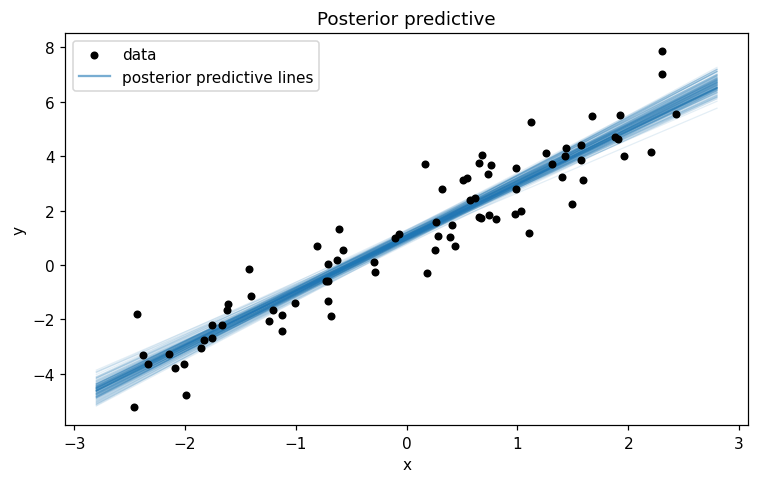

In [7]:
idx = np.random.default_rng(13).choice(post.shape[0], 150, replace=False)
post_lines = model.predictive_draws(post[idx], grid_X)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(grid_x, post_lines.T, color="C0", alpha=0.12, lw=0.8)
ax.scatter(x, y, s=18, color="k", zorder=3, label="data")
ax.plot([], [], color="C0", alpha=0.6, label="posterior predictive lines")
ax.set(xlabel="x", ylabel="y", title="Posterior predictive")
ax.legend()
fig.tight_layout()
plt.show()

## Posterior predictive: the best line with bounds

Reading the ensemble as summaries: the posterior mean line, the 90% credible
band for the line (uncertainty in $\beta$ alone) and the wider 90% predictive
band (adding the observation noise $\sigma$). The predictive band is the one
that should contain roughly 90% of new observations, which the Calibration
notebook checks directly.

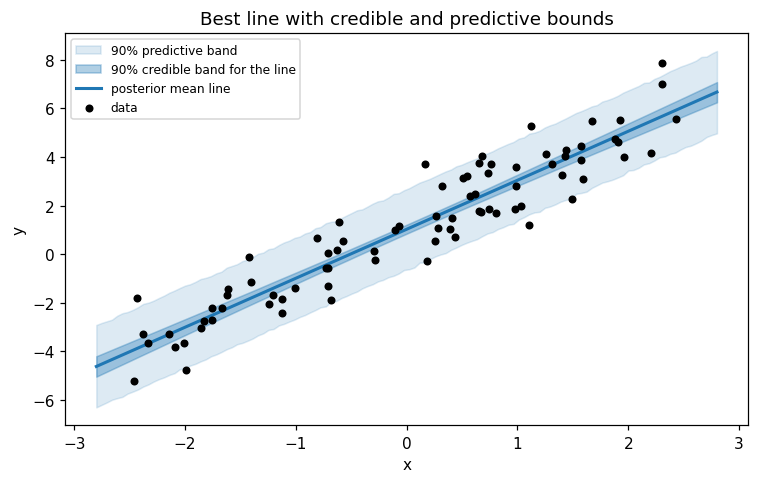

In [8]:
lines = model.predictive_draws(post, grid_X)                                   # no noise
preds = model.predictive_draws(post, grid_X, np.random.default_rng(14))         # plus noise
mean_line = lines.mean(0)
cred_lo, cred_hi = np.quantile(lines, [0.05, 0.95], axis=0)
pred_lo, pred_hi = np.quantile(preds, [0.05, 0.95], axis=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.fill_between(grid_x, pred_lo, pred_hi, color="C0", alpha=0.15, label="90% predictive band")
ax.fill_between(grid_x, cred_lo, cred_hi, color="C0", alpha=0.35, label="90% credible band for the line")
ax.plot(grid_x, mean_line, color="C0", lw=2, label="posterior mean line")
ax.scatter(x, y, s=18, color="k", zorder=3, label="data")
ax.set(xlabel="x", ylabel="y", title="Best line with credible and predictive bounds")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Saving the inputs for the Calibration notebook

Two more items are produced here. 

First a held-out test set from the same
process, with the posterior predictive evaluated at each point, for the PIT
and coverage checks.

Second the simulation-based calibration runs: many small
datasets drawn from the prior, refitted, with the rank of each true value
recorded. This is the slow step: all of it is written to the run directory
for the Calibration notebook to interpret.

In [9]:
# Held-out test set and its posterior predictive draws (a 2000-draw subsample
# of the posterior is plenty for the calibration checks).
test_rng = np.random.default_rng(50)
n_test = 400
x_test = test_rng.uniform(-2.5, 2.5, n_test)
X_test = np.column_stack([np.ones(n_test), x_test])
y_test = X_test @ beta_true + sigma_true * test_rng.standard_normal(n_test)
pred = model.predictive_draws(post[::4], X_test, np.random.default_rng(51)).T   # (n_test, 2000)
pd.DataFrame({"x_test": x_test, "y_test": y_test}).to_parquet(RUN_DIR / "test_set.parquet")
pd.DataFrame(pred, columns=[f"d{i}" for i in range(pred.shape[1])]).to_parquet(
    RUN_DIR / "predictive.parquet")

# Simulation-based calibration: prior draw -> simulate -> refit -> rank the truth.
n_sims, sbc_draws, thin = 400, 300, 3
prior_rng = np.random.default_rng(100)
sim_rng = np.random.default_rng(200)
ranks = np.empty((n_sims, 3), dtype=int)
for i in range(n_sims):
    theta = model.prior_draws(1, prior_rng)[0]                  # true (beta_0, beta_1, sigma)
    y_sim = X @ theta[:2] + theta[2] * sim_rng.standard_normal(n)
    sim_model = LinearGaussian(X, y_sim, m0, V0, a0, b0)
    sc = SamplerConfig(n_chains=1, n_draws=sbc_draws, step_size=0.3,
                       metric=matched_metric(sim_model), seed=i, n_burnin=400)
    r = sample(sim_model, sc)
    # Constrained draws (beta_0, beta_1, sigma), thinned towards independence.
    drawn = np.column_stack([r.positions[0, :, :2], np.exp(r.positions[0, :, 2])])[::thin]
    ranks[i] = rank_statistic(theta[None, :], drawn[None, :, :])[0]
L = drawn.shape[0]
pd.DataFrame(ranks, columns=["beta_0", "beta_1", "sigma"]).to_parquet(RUN_DIR / "sbc_ranks.parquet")
pd.DataFrame([{"n_sims": n_sims, "n_thinned": L}]).to_parquet(RUN_DIR / "sbc_meta.parquet")
print("wrote:", sorted(p.name for p in RUN_DIR.glob("*.parquet")))

wrote: ['draws.parquet', 'predictive.parquet', 'run_config.parquet', 'sample_stats.parquet', 'sbc_meta.parquet', 'sbc_ranks.parquet', 'test_set.parquet']


## Where next

The posterior recovers the generating line and quantifies how sure it is
about it. Two questions remain, one per companion notebook: did the sampler
actually converge (Diagnostics) and is the uncertainty it reports honest
(Calibration). Both read the run saved here.